# SPA capability set vs. actual visits

In [1]:
%load_ext autoreload
%autoreload 2
%cd D:\netmob25

D:\netmob25


In [14]:
import os
os.environ['USE_PYGEOS'] = '0'
import pandas as pd
import geopandas as gpd
import h3.api.numpy_int as h3
from tqdm import tqdm
from shapely.geometry import Polygon
import numpy as np
from scipy.stats import hypergeom
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib as mpl
from joblib import Parallel, delayed
from tqdm import tqdm

In [3]:
file_path = "dbs/data_p/commuter_sp_set_r.parquet"
df_set = pd.read_parquet(file_path)

In [4]:
poi_set = df_set['poi_id'].unique()
print(len(poi_set))

44333


In [5]:
gdf_poi = gpd.read_file('dbs/geo/pois.gpkg')
gdf_poi = gdf_poi[gdf_poi['id'].isin(poi_set)]

In [6]:
gdf_poi['lat'], gdf_poi['lon'] = gdf_poi.geometry.y, gdf_poi.geometry.x

In [7]:
h3_resolution = 8

Calculating H3 IDs: 100%|██████████| 44146/44146 [00:00<00:00, 122939.24it/s]


<Axes: >

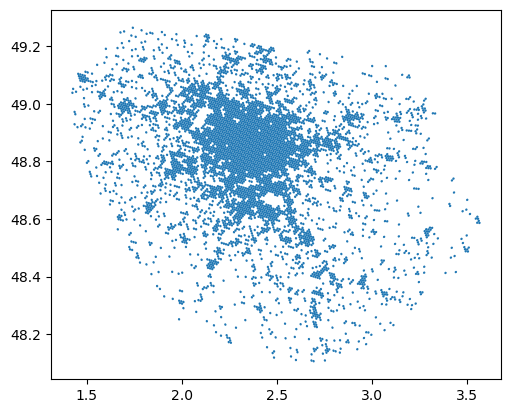

In [8]:
# Concatenate and drop duplicates
unique_coords = gdf_poi[['lon', 'lat']].drop_duplicates()

# Reset index for clarity
unique_coords = unique_coords.reset_index(drop=True)

# Get corresponding h3 id (10) for each coordinate pair
tqdm.pandas(desc="Calculating H3 IDs")
unique_coords['h3_id'] = unique_coords.progress_apply(lambda row: h3.latlng_to_cell(row['lat'], row['lon'], res=h3_resolution), axis=1)
# Extract unique h3_ids
h3_list = unique_coords['h3_id'].unique().tolist()
polygons = [Polygon(h3.cells_to_geo([x])['coordinates'][0]) for x in h3_list]

# Create a GeoDataFrame from unique h3_ids
gdf_h3 = gpd.GeoDataFrame(
    h3_list,
    geometry=polygons,
    crs="EPSG:4326"
)
gdf_h3.columns= ['h3_id', 'geometry']
gdf_h3.plot()

In [9]:
gdf_poi_r = gpd.sjoin(gdf_poi, gdf_h3)
gdf_poi_r = gdf_poi_r[['id', 'h3_id']]

In [10]:
df_set_r = df_set.merge(gdf_poi_r, left_on='poi_id', right_on='id', how='left')
df_set_r.head()

,ID,poi_id,time_left,mode,id,h3_id
0,16_4000,08f1fb4670bb338a03a0f7c1eb8d83f2,2.0,pt,08f1fb4670bb338a03a0f7c1eb8d83f2,613047304257011711
1,16_4000,08f1fb4670bb338a03a0f7c1eb8d83f2,2.0,pt,08f1fb4670bb338a03a0f7c1eb8d83f2,613047304257011711
2,16_4000,08f1fb4670bb338a03a0f7c1eb8d83f2,2.0,pt,08f1fb4670bb338a03a0f7c1eb8d83f2,613047304257011711
3,16_4000,08f1fb4670bb338a03a0f7c1eb8d83f2,2.0,pt,08f1fb4670bb338a03a0f7c1eb8d83f2,613047304257011711
4,16_4000,08f1fb4670bb338a03a0f7c1eb8d83f2,2.0,pt,08f1fb4670bb338a03a0f7c1eb8d83f2,613047304257011711


In [11]:
df_set_r = df_set_r.groupby(['ID', 'mode', 'h3_id'])['time_left'].mean().reset_index()

In [12]:
df = pd.read_parquet(f'dbs/data_p/stays_extraction_all.parquet')

In [13]:
THIRD = {'LEISURE'}
def third_place_visits_h3(group):
    acts = [group['purpose_o'].tolist()[0]] + group['purpose_d'].tolist()
    # Filter third places
    third_places = [x for x in acts if x in THIRD]
    n = len(third_places)

    if n == 0:
        return pd.Series({'h3_visits': []})
    # --- 2) Build lists of coordinate pairs (lat, lon) ---
    # (a) Flat list of all start+end coords across the whole dataframe
    all_coords = (
        list(zip(group["start_lat"], group["start_lon"])) +
        list(zip(group["end_lat"],   group["end_lon"]))
    )
    # Drop NaNs
    all_coords = [(lat, lon) for lat, lon in all_coords
                if pd.notna(lat) and pd.notna(lon)]

    # --- 3) Corresponding H3 r=10 for those coords (same order as all_coords) ---
    all_h3_r10 = [h3.latlng_to_cell(lat, lon, res=h3_resolution) for lat, lon in all_coords]
    all_h3_r10 = [h for h in all_h3_r10 if pd.notna(h)]

    return pd.Series({'h3_visits': list(set(all_h3_r10))})

df_v = df.groupby('ID').apply(third_place_visits_h3).reset_index()

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_21524\1738379779.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_v = df.groupby('ID').apply(third_place_visits_h3).reset_index()


## 1. Individual sampling

In [ ]:
id_list = df_v.ID.values
feasible_id = []
for i in tqdm(id_list):
    set_s = df_set_r.loc[df_set_r['ID'] == i, :].copy()
    if len(set_s) > 0:
        set_v = df_v.loc[df_v['ID'] == i, 'h3_visits'].values[0]  # a list of visited h3_id (unique)
        if len(set_v) > 0:
            feasible_id.append(i)
        break

In [18]:
set_s.sort_values(by='time_left', ascending=False, inplace=True)
set_s['rank'] = np.arange(1, len(set_s) + 1)

In [15]:
# Define the worker function
def check_feasibility(i):
    set_s = df_set_r.loc[df_set_r['ID'] == i, :]
    if len(set_s) > 0:
        set_v = df_v.loc[df_v['ID'] == i, 'h3_visits'].values
        if len(set_v) > 0 and len(set_v[0]) > 0:
            return i
    return None

# List of IDs
id_list = df_v.ID.values

# Run in parallel
feasible_id = Parallel(n_jobs=-1)(
    delayed(check_feasibility)(i) for i in tqdm(id_list)
)

# Filter out None results
feasible_id = [i for i in feasible_id if i is not None]

100%|██████████| 3318/3318 [03:32<00:00, 15.64it/s]


In [16]:
def mean_rank_test(visited_ids, df_ranked, B=1000, random_seed=42):
    np.random.seed(random_seed)

    feasible_ids = df_ranked['h3_id'].tolist()
    rank_dict = dict(zip(df_ranked['h3_id'], df_ranked['rank']))
    N_i = len(feasible_ids)

    # Filter only visited places within feasible set
    visited_in_spa = [h for h in visited_ids if h in rank_dict]
    k_i = len(visited_in_spa)

    if k_i == 0:
        return {
            'T_mean_act': np.nan,
            'mu_null': np.nan,
            'sigma_null': np.nan,
            'd_i': np.nan,
            'p_empirical': np.nan,
            'note': 'No visited h3_id in SPA'
        }

    T_act = np.mean([rank_dict[h] for h in visited_in_spa])

    null_T = []
    for _ in range(B):
        rand_draw = np.random.choice(feasible_ids, size=k_i, replace=False)
        null_T.append(np.mean([rank_dict[h] for h in rand_draw]))
    null_T = np.array(null_T)

    p_val = (1 + np.sum(null_T <= T_act)) / (B + 1)
    mu_null = np.mean(null_T)
    sigma_null = np.std(null_T, ddof=1)
    d_i = (T_act - mu_null) / sigma_null if sigma_null > 0 else np.nan

    return {
        'T_mean_act': T_act,
        'mu_null': mu_null,
        'sigma_null': sigma_null,
        'd_i': d_i,
        'p_empirical': p_val,
        'k_i': k_i,
        'excluded_visits': len(visited_ids) - k_i
    }

In [20]:
res1 = mean_rank_test(set_v, set_s)
print("Mean Rank Test:", res1)

Mean Rank Test: {'T_mean_act': 579.6666666666666, 'mu_null': 1690.481, 'sigma_null': 371.2326601176803, 'd_i': -2.9922322378133606, 'p_empirical': 0.001998001998001998, 'k_i': 6, 'excluded_visits': 8}


## 2. Scale up to all individuals

In [22]:
test_results = []
for i in tqdm(feasible_id):
    set_s = df_set_r.loc[df_set_r['ID'] == i, :].copy()
    set_v = df_v.loc[df_v['ID'] == i, 'h3_visits'].values[0]  # a list of visited h3_id (unique)
    set_s.sort_values(by='time_left', ascending=False, inplace=True)
    set_s.loc[:, 'rank'] = np.arange(1, len(set_s) + 1)
    res1 = mean_rank_test(set_v, set_s)
    res1['ID'] = i
    test_results.append(res1)
df_m = pd.DataFrame(test_results)

100%|██████████| 856/856 [02:02<00:00,  6.98it/s]


In [23]:
df_m['k_i'] = df_m['k_i'].fillna(0)
df_m['excluded_visits'] = df_m['excluded_visits'].fillna(99999)

In [24]:
len(df_m[df_m['k_i'] == 0]) / len(df_m) * 100

0.11682242990654204

In [25]:
df_m.loc[:, 'excluded_share'] = df_m.loc[:, 'excluded_visits'] / (df_m.loc[:, 'k_i'] + df_m.loc[:, 'excluded_visits'])
df_m.loc[:, 'excluded_share'] = df_m.apply(lambda row: row['excluded_share'] if row['k_i'] > 0 else 1, axis=1)

In [26]:
df_p = pd.read_csv("dbs/data_p/commuter_model_features_r.csv")
df_m_r = df_m.merge(df_p[['ID', 'Gender', 'poverty_rate',
       'main_mode_r', 'Age', 'Education', 'Household_type', 'weight_ind',
       'codgeo', 'pt_sub', 'active_mode']], on='ID', how='left')
df_m_r.head()

,T_mean_act,mu_null,sigma_null,d_i,p_empirical,k_i,excluded_visits,ID,note,excluded_share,Gender,poverty_rate,main_mode_r,Age,Education,Household_type,weight_ind,codgeo,pt_sub,active_mode
0,97.666667,243.676778,32.814919,-4.449504,0.000999,9.0,0.0,10_2980,NaN,0.000000,Man,15.800493,Active/Micro,30.0,5.0,0.0,1375.000372,75120.0,True,1.0
1,376.100000,418.229000,73.658658,-0.571949,0.290709,10.0,0.0,10_2984,NaN,0.000000,Woman,8.000000,Car,39.0,5.0,0.0,843.194726,78073.0,True,0.0
2,35.555556,317.642556,60.122540,-4.691868,0.000999,9.0,5.0,10_2993,NaN,0.357143,Woman,11.000000,Car,55.0,9.0,6.0,1113.895194,77445.0,False,0.0
3,15.272727,39.906545,6.542534,-3.765180,0.000999,11.0,2.0,10_2994,NaN,0.153846,Man,11.000000,Active/Micro,44.0,9.0,6.0,3936.409843,75115.0,True,1.0
4,439.250000,964.481833,160.184890,-3.278910,0.000999,12.0,1.0,10_2998,NaN,0.076923,Man,15.800493,Car,32.0,4.0,6.0,1528.693295,91587.0,False,0.0


## 3. Visualize the results

In [28]:
# ----- 1. Effect on excluded share -----
model_entropy = smf.ols(
    formula="excluded_share ~ poverty_rate + C(pt_sub) + C(active_mode) + C(main_mode_r) + C(Household_type)",    # + Age + C(Education) + C(Gender) +
    data=df_m_r
).fit(weights=df_m_r["weight_ind"])

print("\n--- Excluded share model (weighted) ---")
print(model_entropy.summary())


--- Excluded share model (weighted) ---
                            OLS Regression Results                            
Dep. Variable:         excluded_share   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     2.973
Date:                tor, 04 sep 2025   Prob (F-statistic):           0.000695
Time:                        13:53:48   Log-Likelihood:                 42.412
No. Observations:                 856   AIC:                            -60.82
Df Residuals:                     844   BIC:                            -3.798
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [29]:
df_m['excluded_share'].describe()

count    856.000000
mean       0.214412
std        0.234829
min        0.000000
25%        0.000000
50%        0.150000
75%        0.333333
max        1.000000
Name: excluded_share, dtype: float64

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_21524\1239495865.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df_m_r.groupby('bin').size()
C:\Users\yuanlia\AppData\Local\Temp\ipykernel_21524\1239495865.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  car_counts = df_m_r[df_m_r['main_mode_r'] == 'Car'].groupby('bin').size()


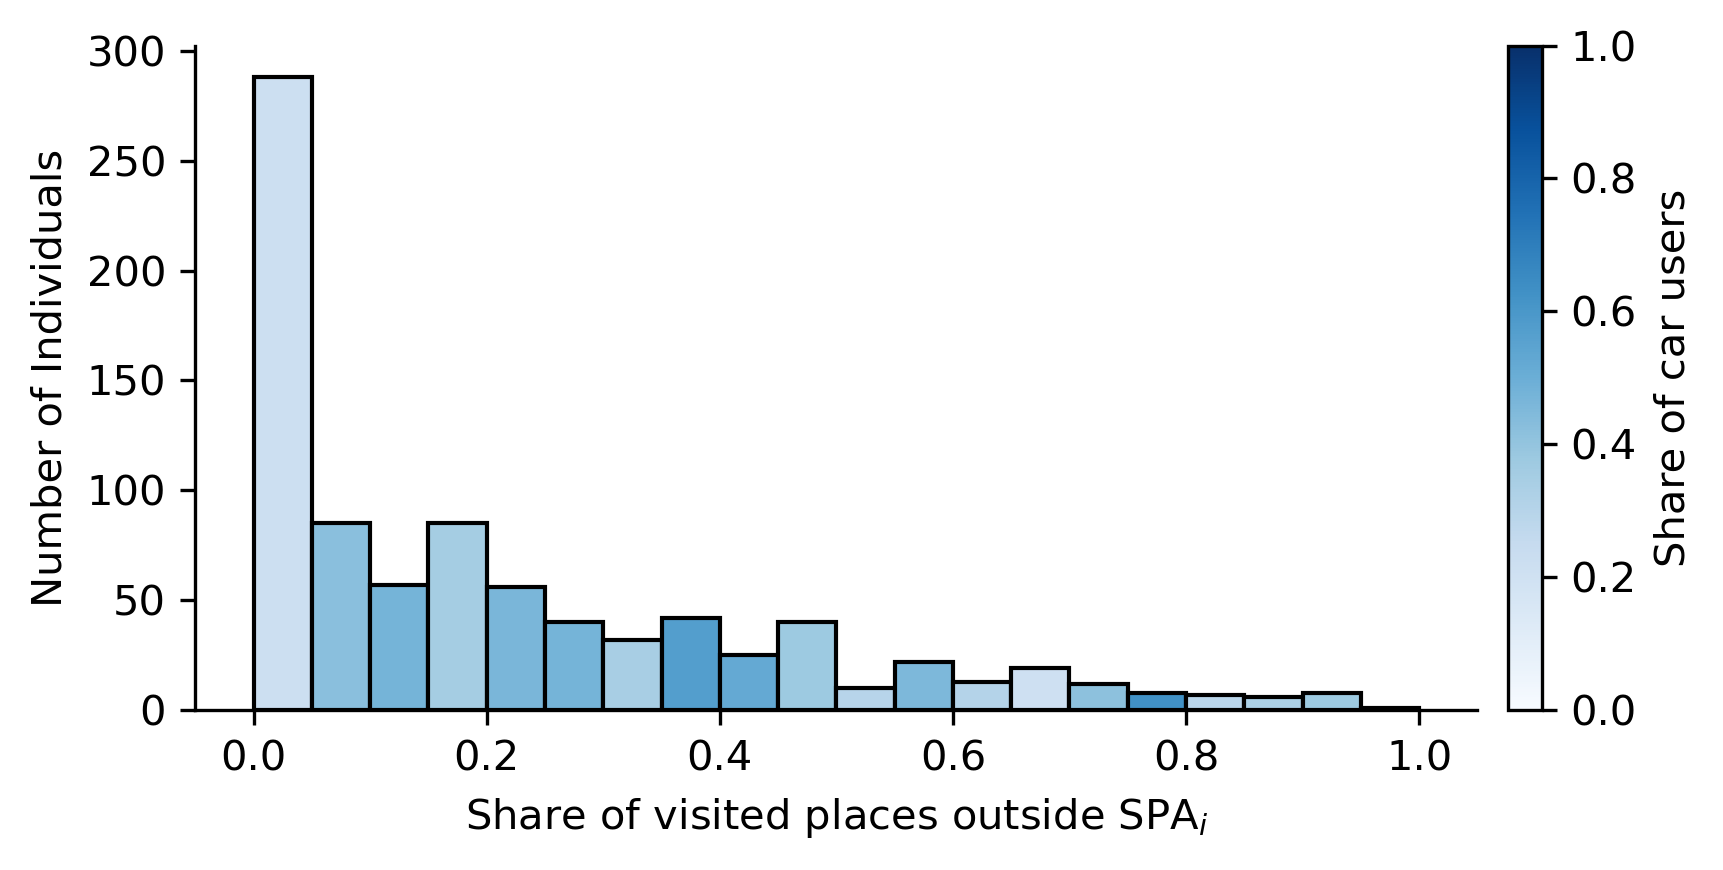

In [30]:
# Step 1: Bin the data
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
df_m_r['bin'] = pd.cut(df_m_r['excluded_share'], bins=bins, include_lowest=True)

# Step 2: Count total and car users in each bin
bin_counts = df_m_r.groupby('bin').size()
car_counts = df_m_r[df_m_r['main_mode_r'] == 'Car'].groupby('bin').size()

# Align and compute car share
car_share = (car_counts / bin_counts).fillna(0)

# Step 3: Create colored bars using car share
colors = cm.Blues(car_share.values)  # You can change colormap here

# Step 4: Plot
fig, ax = plt.subplots(1, 1, figsize=(6, 3), dpi=300)

# Bar heights (total individuals per bin)
heights = bin_counts.values
lefts = bins[:-1]
width = bins[1] - bins[0]

# Draw bars one by one with color
for i in range(len(heights)):
    ax.bar(lefts[i], heights[i], width=width, align='edge', 
           color=colors[i], edgecolor='black', alpha=1)

# Labels and aesthetics
ax.set_xlabel("Share of visited places outside SPA$_i$")
ax.set_ylabel("Number of Individuals")
# ax.set_title("Distribution of Excluded Visits\nColored by Car User Share")
sns.despine(ax=ax)

sm = cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])  # Needed for ScalarMappable
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Share of car users')

plt.tight_layout()
fig.savefig("figures/selectivity_excluded_share.png", dpi=300, bbox_inches='tight')
plt.show()

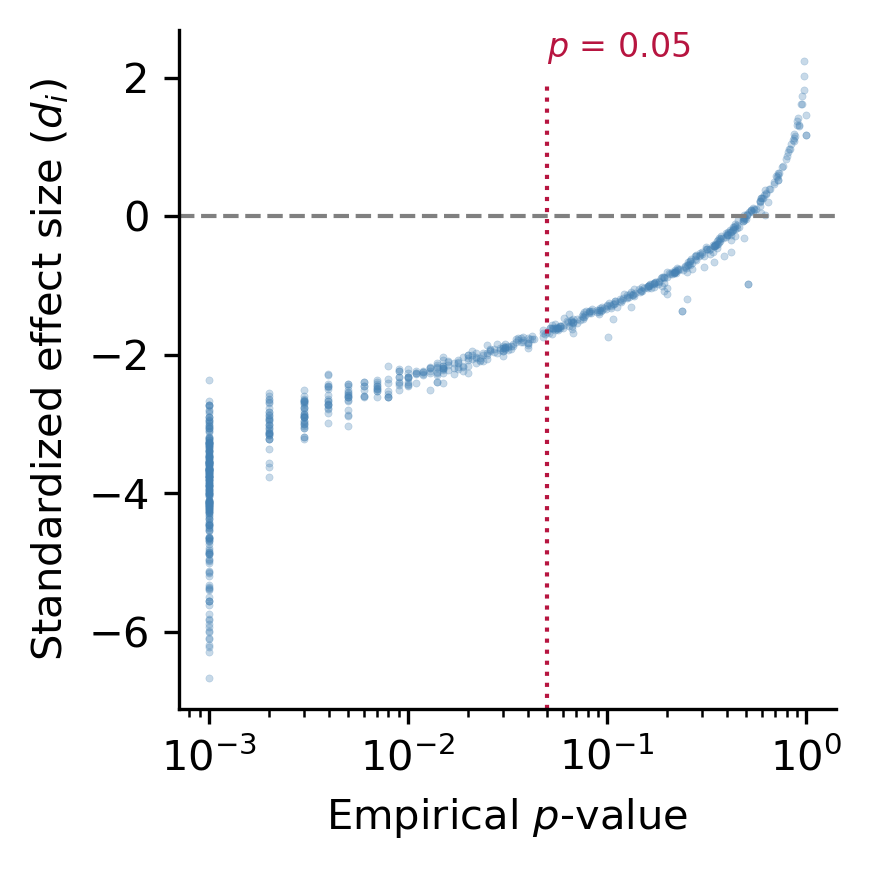

In [31]:
# Drop NaNs
df2plot = df_m_r.dropna(subset=['d_i', 'p_empirical'])

# Set up figure
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)

# Base scatterplot
sns.scatterplot(
    data=df2plot,
    x='p_empirical',
    y='d_i',
    alpha=0.3,
    edgecolor=None,
    s=3,
    color='steelblue'
)

# Reference lines
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0.05, color='#b71540', linestyle=':', linewidth=1)
plt.text(
    0.05,                # x position
    plt.ylim()[1],       # top of the y-axis
    '$p$ = 0.05',          # label text
    color='#b71540',
    ha='left', va='top',
    fontsize=8,
    rotation=0,
    backgroundcolor='white'
)
# Labels and title
plt.xlabel("Empirical $p$-value")
plt.ylabel("Standardized effect size ($d_i$)")
# plt.title("Selectivity in Spatial Choices\n(p-value vs. Effect Size)")

# Clean up
sns.despine()
plt.xscale('log')
plt.tight_layout()
fig.savefig("figures/selectivity_effect_size.png", dpi=300, bbox_inches='tight')
plt.show()

In [32]:
len(df2plot[df2plot['p_empirical'] < 0.05]) / len(df2plot)

0.6266195524146054

In [33]:
cat_dict = {'entropy_mm': 'Leisure activity participation', 
            'activity_time_third': 'Leisure activity participation', 
            'total_travel_time': "Trip making", 'xs_total_hws': "Trip making", 
            'trip_chaining_presence': "Trip making", 
            'Gender': "Individual attributes", 
            #'main_mode_r': "Transport mode", 
            'Age': "Individual attributes", 
            'Education': "Individual attributes", 
            'Household_type': "Individual attributes", 
            'weight_ind': "Individual attributes", 
            'mode': "Transport mode", 
            'ak_cat': "Space-time accessibility", 
            'ak_log': "Space-time accessibility", 
            'pt_sub': "Transport mode", 
            'active_mode': "Individual attributes"}
cat_name_dict = {'entropy_mm': 'Third activity entropy', 
            'activity_time_third': 'Third activity time (min)', 
            'total_travel_time': "Total travel time (min)", 'xs_total_hws': "Trip chaining complexity", 
            'trip_chaining_presence': "Trip chaining presence", 
            'Gender': "Gender", 
            # 'main_mode_r': "Main transport mode", 
            'Age': "Age", 
            'Education': "Education", 
            'Household_type': "Household type", 
            'weight_ind': "Individual attributes", 
            'mode': "Main transport mode", 
            'ak_cat': "Space-time accessibility (> 0)", 
            'ak_log': "Space-time accessibility (log)", 
            'pt_sub': "Public transit subscription", 
            'active_mode': "Use of active mode"}
cat_list = ['trip_chaining_presence', 'Gender', 'Education', 'Household_type', 'mode', 'ak_cat', 'pt_sub', 'active_mode']
cat_level_dict = dict()
Education_dict = {
    'No diploma': 0,
    'Vocational': 1,
    'Lower secondary': 2,
    'Upper secondary': 3,
    '3–4-year higher education': 4,
    "5-year-and-above higher education": 5,
    "Missing": 9
}
household_order = {
    'Other': 0,
    'Other': 1,
    'Single parent': 2,
    'Living with parent(s)': 3,
    'Other': 4,
    'Other': 5,
    'In a couple w/ child(ren)': 6,
    'Other': 7
}
cat_level_dict['Education'] = {v: k for k, v in Education_dict.items()}
cat_level_dict['trip_chaining_presence'] = {0: 'w/o', 1: 'w/'}
cat_level_dict['Gender'] = {'Woman': 'Woman', 'Man': 'Man'}
cat_level_dict['Household_type'] = {v: k for k, v in household_order.items()}
cat_level_dict['mode'] = {'Car': 'Car', 'Public transit': 'Public transit'}
cat_level_dict['ak_cat'] = {'Zero': 'Zero', 'Non-zero': 'Non-zero'}
cat_level_dict['pt_sub'] = {True: 'Yes', False: 'No'}
cat_level_dict['active_mode'] = {1: 'Yes', 0: 'No'}

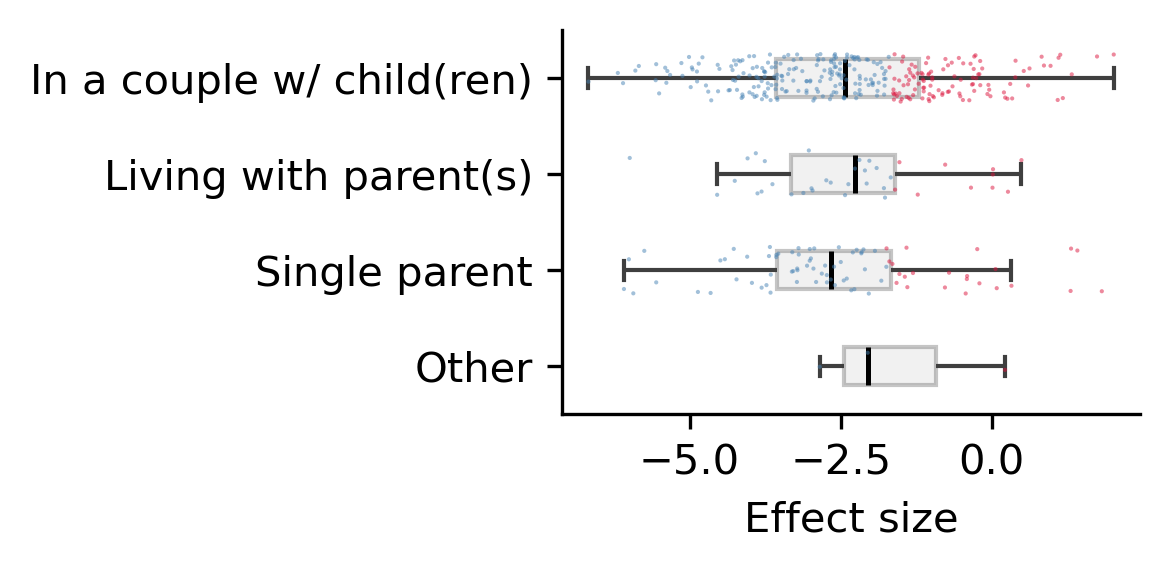

In [35]:
# Drop missing values
df2plot = df_m_r.dropna(subset=['d_i', 'Household_type', 'p_empirical']).copy()

# Map categorical labels if needed
df2plot['active_mode'] = df2plot['active_mode'].map(cat_level_dict['active_mode'])
df2plot['Household_type'] = df2plot['Household_type'].map(cat_level_dict['Household_type'])

# Flag significance
df2plot['is_significant'] = df2plot['p_empirical'] < 0.05

# Set up horizontal plot
fig, ax = plt.subplots(1, 1, figsize=(4, 2), dpi=300)

# Boxplot (horizontal)
sns.boxplot(
    data=df2plot,
    y='Household_type',
    x='d_i',
    width=0.4,
    showcaps=True,
    showfliers=False,
    boxprops=dict(alpha=0.3, linewidth=1, facecolor='lightgray'),
    whiskerprops=dict(linewidth=1),
    medianprops=dict(color='black', linewidth=1.2)
)

# Jitter plot overlaid
sns.stripplot(
    data=df2plot,
    y='Household_type',
    x='d_i',
    hue='is_significant',
    palette={False: 'crimson', True: 'steelblue'},
    jitter=0.25,
    dodge=False,
    alpha=0.5,
    size=1,
    legend=False
)

# Labels
plt.ylabel("")
plt.xlabel("Effect size")
sns.despine()
plt.tight_layout()
plt.show()

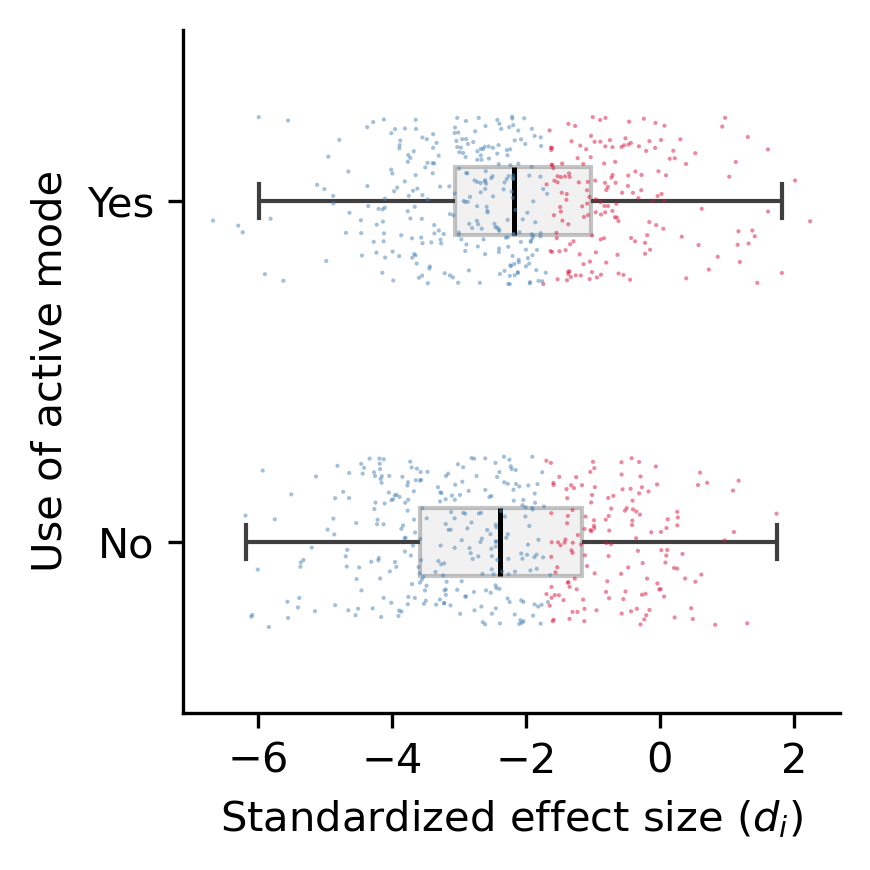

In [36]:
# Set up horizontal plot
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)

# Boxplot (horizontal)
sns.boxplot(
    data=df2plot,
    y='active_mode',
    x='d_i',
    width=0.2,
    showcaps=True,
    showfliers=False,
    boxprops=dict(alpha=0.3, linewidth=1, facecolor='lightgray'),
    whiskerprops=dict(linewidth=1),
    medianprops=dict(color='black', linewidth=1.2)
)

# Jitter plot overlaid
sns.stripplot(
    data=df2plot,
    y='active_mode',
    x='d_i',
    hue='is_significant',
    palette={False: 'crimson', True: 'steelblue'},
    jitter=0.25,
    dodge=False,
    alpha=0.5,
    size=1,
    legend=False
)

# Labels
plt.ylabel("Use of active mode")
plt.xlabel("Standardized effect size ($d_i$)")
sns.despine()
plt.tight_layout()
fig.savefig("figures/selectivity_active_mode.png", dpi=300, bbox_inches='tight')
plt.show()

In [37]:
# ----- 1. Effect on entropy_mm -----
model_entropy = smf.ols(
    formula="d_i ~ poverty_rate + C(main_mode_r) + C(active_mode) + C(Household_type)",
    data=df2plot
).fit(weights=df2plot["weight_ind"])

print("\n--- Effect size model (weighted) ---")
print(model_entropy.summary())


--- Effect size model (weighted) ---
                            OLS Regression Results                            
Dep. Variable:                    d_i   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     3.251
Date:                tor, 04 sep 2025   Prob (F-statistic):            0.00390
Time:                        13:55:45   Log-Likelihood:                -808.97
No. Observations:                 431   AIC:                             1632.
Df Residuals:                     424   BIC:                             1660.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------